In [1]:
import os
# Force CPU backend on Apple Silicon to avoid Metal issues
os.environ['JAX_PLATFORMS'] = 'cpu'

import matplotlib.pyplot as plt

# Disable LaTeX rendering in matplotlib
plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "sans-serif"

from jax import random
from jax import numpy as jnp
from sbijax import plot_loss_profile

from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.simulator import PatchForagingDDM_JAX, create_prior
from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.snle.snle_inference_jax import train_snle, infer_parameters_snle
from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.snle.snle_utils_jax import plot_real_synth_hist, extract_samples


1. Training SNLE model...

Initializing SNLE (multi mode)...
Data dimension: 37

Simulating 750000 training samples...
Training data shapes: theta=(750000, 4), x=(750000, 37)
Training SNLE...


 23%|██▎       | 234/1000 [1:01:34<3:21:35, 15.79s/it]



SNLE training complete (multi mode)!
Trained for 235 iterations


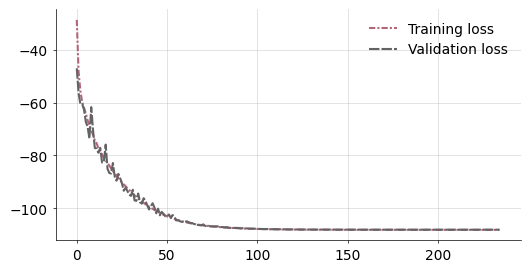

In [2]:
# --- Setup ---
num_window_sites = 100
n_simulations = 750_000
simulator = PatchForagingDDM_JAX(max_sites_per_window=num_window_sites)

# Get prior bounds for JAX simulator
prior_fn = create_prior()
rng_key = random.PRNGKey(0)

# --- Train SNLE ---
print("\n1. Training SNLE model...")
snle, snle_params, losses, rng_key, y_mean, y_std = train_snle(
    simulator, 
    prior_fn,
    mode='multi', 
    n_simulations=n_simulations,
    num_layers = 12,
    n_iter=1000,                        # Ensure full 1000 iterations possible
    n_early_stopping_patience=30,       # More patience for convergence
    batch_size=512,                     # Can adjust based on memory
    percentage_data_as_validation_set = .1, #.1 is default try .2
    rng_key=rng_key
)

# Disable LaTeX rendering in matplotlib
plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "sans-serif"

_, axes = plt.subplots(figsize=(6, 3))
plot_loss_profile(losses, axes)
plt.show()

In [3]:
losses

Array([[ -28.760355,  -47.064625],
       [ -48.355286,  -56.414494],
       [ -55.666233,  -60.618137],
       [ -59.821014,  -60.589714],
       [ -61.912277,  -62.61401 ],
       [ -64.10558 ,  -67.26377 ],
       [ -66.73492 ,  -69.178635],
       [ -68.552086,  -73.58434 ],
       [ -70.25784 ,  -61.72855 ],
       [ -72.262886,  -70.39543 ],
       [ -74.33285 ,  -77.18098 ],
       [ -75.41216 ,  -77.34099 ],
       [ -77.32022 ,  -78.97837 ],
       [ -78.326706,  -77.09528 ],
       [ -79.61028 ,  -82.690926],
       [ -80.92131 ,  -82.411285],
       [ -81.86592 ,  -75.88393 ],
       [ -82.80885 ,  -84.99685 ],
       [ -83.77958 ,  -86.62013 ],
       [ -84.87923 ,  -86.82601 ],
       [ -85.889595,  -82.84336 ],
       [ -86.79579 ,  -87.95505 ],
       [ -87.59527 ,  -89.52283 ],
       [ -88.54648 ,  -86.95381 ],
       [ -89.34909 ,  -88.548454],
       [ -90.10669 ,  -90.53114 ],
       [ -90.96938 ,  -93.32888 ],
       [ -91.563416,  -92.19411 ],
       [ -92.37939 ,

In [4]:
# --- Simulate observed data ---
print("\n2. Simulating observed data...")
rng_key, subkey = random.split(rng_key)
true_theta = prior_fn().sample(seed=subkey)['theta']
rng_key, subkey = random.split(rng_key)
_, observed_stats = simulator.simulate_one_window(true_theta, subkey)
print(f"   True theta: {true_theta}")
print(f"   Observed stats: {observed_stats}")


2. Simulating observed data...
   True theta: [0.45471653 0.774107   1.1059248  0.45818153]
   Observed stats: [ 1.1454346e+01  3.9120460e+00  2.7668691e+00  7.9999995e-01
  3.9999998e-01  5.1999998e-01  4.9959987e-01  4.2262120e+00
  3.4353967e+00  2.3045013e+00  3.3966389e+00  3.8532803e+00
  3.0281918e+00 -8.9073308e-02 -8.2508850e-01  4.7873359e+00
  1.5931206e+00  3.3156495e+00  5.3862453e+00  3.7931247e+00
  9.9010092e-01  3.6005408e-01  1.0007831e+00  6.4999998e-01
  4.7826923e+01  6.4999998e-01  8.0000000e+01  1.2500000e+00
  7.9999995e-01  5.4528767e-01  9.8871809e-01  3.2081336e-01
 -4.0262735e-01  2.5868545e+00  7.4239470e-02  3.1416607e-01
  4.7664928e-01]


In [5]:
# --- Run inference ---
print("\n3. Testing inference...")
rng_key, subkey = random.split(rng_key)
posterior_samples, diagnostics = infer_parameters_snle(
snle,
snle_params,
observed_stats, 
y_mean, y_std,
num_samples=100_000,
num_warmup=50,
num_chains=2,
rng_key=subkey
)


3. Testing inference...

Normalizing observed statistics...
Observed stats (raw): [ 1.1454346e+01  3.9120460e+00  2.7668691e+00  7.9999995e-01
  3.9999998e-01  5.1999998e-01  4.9959987e-01  4.2262120e+00
  3.4353967e+00  2.3045013e+00  3.3966389e+00  3.8532803e+00
  3.0281918e+00 -8.9073308e-02 -8.2508850e-01  4.7873359e+00
  1.5931206e+00  3.3156495e+00  5.3862453e+00  3.7931247e+00
  9.9010092e-01  3.6005408e-01  1.0007831e+00  6.4999998e-01
  4.7826923e+01  6.4999998e-01  8.0000000e+01  1.2500000e+00
  7.9999995e-01  5.4528767e-01  9.8871809e-01  3.2081336e-01
 -4.0262735e-01  2.5868545e+00  7.4239470e-02  3.1416607e-01
  4.7664928e-01]
Observed stats (normalized): [-0.57070917 -0.52505225 -0.52269316 -0.6088273   0.7222544   0.47139174
  0.503876   -0.54155594 -0.5303188  -0.5575843  -0.35512847 -0.4430127
 -0.69057477 -0.8203158  -0.5304408  -0.28513166 -0.5466371  -0.49881655
 -0.5548294  -0.54764324 -0.19053331  2.6221397   0.2611483   0.672126
 -0.40987083  0.672126   -0.60882

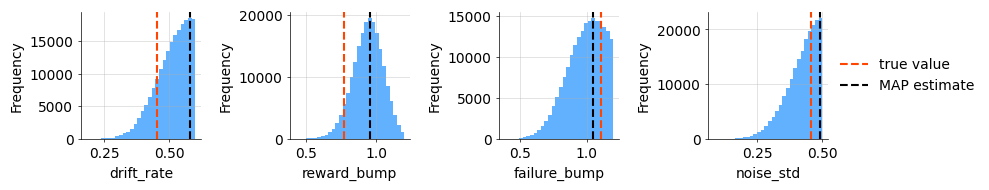

In [6]:
# --- Plot posterior distributions ---
param_names = ["drift_rate", "reward_bump", "failure_bump", "noise_std"]
param_labels = [
    "drift_rate: evidence accumulation rate",
    "reward_bump: evidence boost from receiving reward",
    "failure_bump: evidence boost from not receiving reward",
    "noise_std: std of noise in evidence accumulation"
]

fig, axes = plt.subplots(1, 4, figsize=(10, 2))
axes = axes.flatten()

for i in range(4):

    # Compute histogram
    counts, bins, _ =axes[i].hist(posterior_samples[:, i], bins=30, color='dodgerblue', edgecolor=None, alpha=0.7)

    # Posterior mode (bin center with max count)
    mode_index = jnp.argmax(counts)
    posterior_mode = (bins[mode_index] + bins[mode_index + 1]) / 2

    axes[i].axvline(true_theta[i], color='orangered', linestyle='--', label="true value")
    axes[i].axvline(posterior_mode, color='k', linestyle='--', label='MAP estimate')

    axes[i].set_xlabel(param_names[i])
    axes[i].set_ylabel("Frequency")

axes[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()


In [7]:
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde

def pairplot(posterior_samples, true_params=None, param_names=None, figsize_per_param=2.5, grid_points=100):
    """
    Lower-triangle corner plot with:
    - 2D filled KDEs (off-diagonal)
    - 1D KDEs (diagonal)
    - Red 'X' for true parameters
    """
    if isinstance(posterior_samples, jnp.ndarray):
        posterior_samples = np.array(posterior_samples)
    
    n_params = posterior_samples.shape[1]
    if param_names is None:
        param_names = [f"param{i}" for i in range(n_params)]
    
    fig, axes = plt.subplots(n_params, n_params, figsize=(figsize_per_param*n_params, figsize_per_param*n_params))
    
    for i in range(n_params):
        for j in range(n_params):
            ax = axes[i, j]
            
            # Only fill lower triangle
            if i < j:
                ax.axis('off')
                continue
            
            # Diagonal: 1D KDE
            if i == j:
                data = posterior_samples[:, i]
                kde = gaussian_kde(data)
                x_grid = np.linspace(data.min(), data.max(), grid_points)
                ax.fill_between(x_grid, kde(x_grid), color="skyblue")
                
                if true_params is not None:
                    ax.axvline(true_params[i], color='red', linestyle='--', lw=1)
            
            # Off-diagonal: 2D KDE
            else:
                x = posterior_samples[:, j]
                y = posterior_samples[:, i]
                xy = np.vstack([x, y])
                kde = gaussian_kde(xy)
                x_grid = np.linspace(x.min(), x.max(), grid_points)
                y_grid = np.linspace(y.min(), y.max(), grid_points)
                X, Y = np.meshgrid(x_grid, y_grid)
                Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
                ax.contourf(X, Y, Z, levels=20, cmap="Blues")
                
                if true_params is not None:
                    ax.scatter(true_params[j], true_params[i], c='red', s=50, marker='X', label='True')
            
            # Only label left and bottom axes
            if i < n_params - 1:
                ax.set_xticklabels([])
            else:
                ax.set_xlabel(param_names[j])
            if j > 0:
                ax.set_yticklabels([])
            else:
                ax.set_ylabel(param_names[i])
    
    # Add a legend in the top-left subplot
    handles = []
    if true_params is not None:
        handles.append(plt.Line2D([0], [0], marker='X', color='w', markerfacecolor='red', markersize=8, label='True'))
    axes[0, 1].legend(handles=handles, loc='upper left')
    
    plt.tight_layout()
    plt.show()

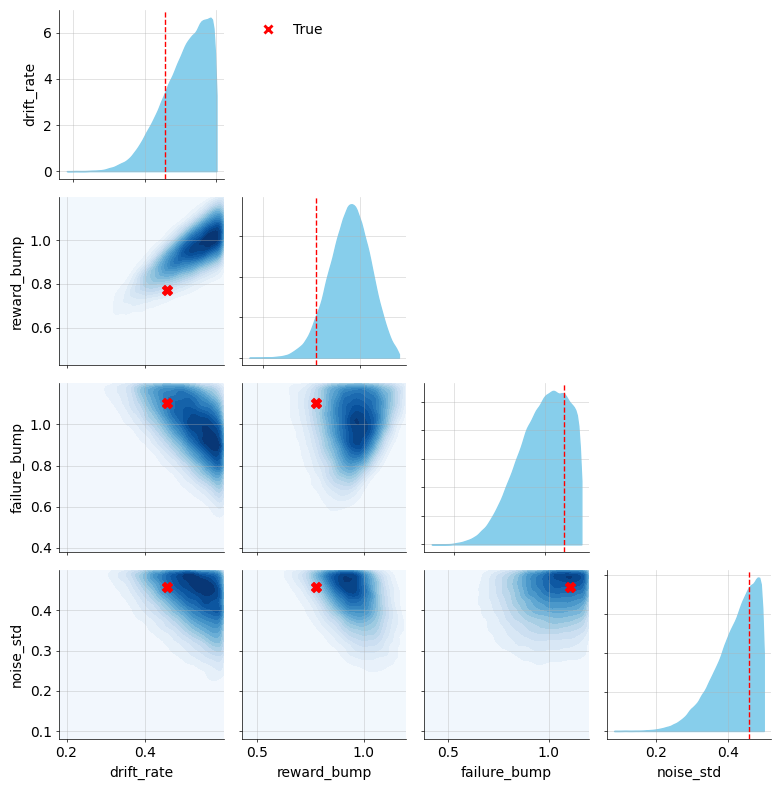

In [8]:
pairplot(posterior_samples, true_theta, param_names, figsize_per_param=2.0)


Generating patches from posterior samples for comparison...

2. Simulating observed data...
['max_time', 'mean_time', 'std_time', 'mean_stops', 'std_stops', 'mean_rewards', 'std_rewards', 'mean_time_after_reward', 'mean_time_after_failure', 'std_time_after_reward', 'std_time_after_failure', 'early_mean', 'late_mean', 'temporal_trend', 'late_minus_early', 'middle_mean', 'p25', 'median', 'p75', 'iqr', 'autocorr_lag1', 'diff_std', 'mean_abs_change', 'reward_rate', 'mean_reward_trial', 'prop_patches_with_reward', 'n_patches', 'mean_sites_per_patch', 'stop_rate']


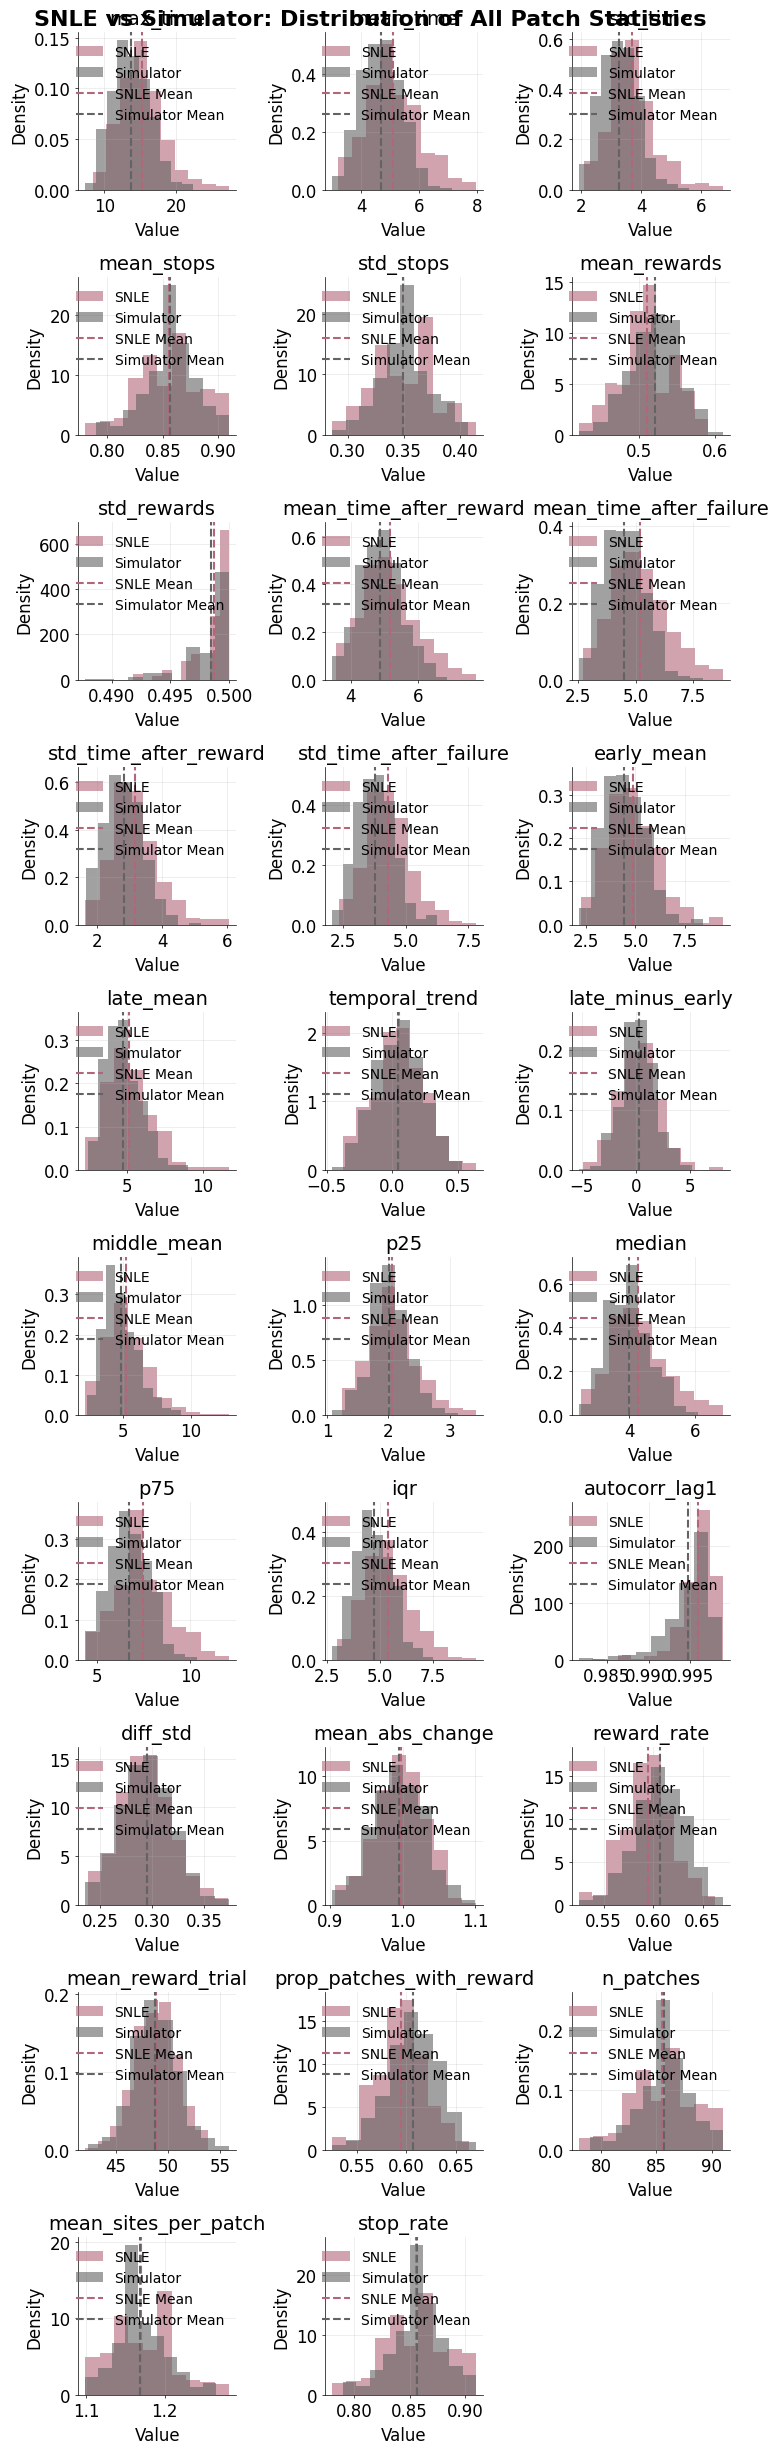


COMPARISON SUMMARY

max_time:
  SNLE:      15.259 ± 3.094
  Simulator: 13.749 ± 2.620

mean_time:
  SNLE:      5.113 ± 0.937
  Simulator: 4.681 ± 0.689

std_time:
  SNLE:      3.693 ± 0.782
  Simulator: 3.258 ± 0.604

mean_stops:
  SNLE:      0.855 ± 0.029
  Simulator: 0.856 ± 0.023

std_stops:
  SNLE:      0.349 ± 0.030
  Simulator: 0.349 ± 0.024

mean_rewards:
  SNLE:      0.509 ± 0.034
  Simulator: 0.520 ± 0.034

std_rewards:
  SNLE:      0.499 ± 0.002
  Simulator: 0.498 ± 0.002

mean_time_after_reward:
  SNLE:      5.148 ± 0.803
  Simulator: 4.872 ± 0.629

mean_time_after_failure:
  SNLE:      5.192 ± 1.224
  Simulator: 4.506 ± 0.865

std_time_after_reward:
  SNLE:      3.160 ± 0.751
  Simulator: 2.813 ± 0.581

std_time_after_failure:
  SNLE:      4.315 ± 0.893
  Simulator: 3.802 ± 0.727

early_mean:
  SNLE:      4.867 ± 1.315
  Simulator: 4.443 ± 1.039

late_mean:
  SNLE:      5.150 ± 1.551
  Simulator: 4.701 ± 1.184

temporal_trend:
  SNLE:      0.051 ± 0.197
  Simulator: 0.045 

In [15]:
# Generate multiple patches from posterior samples to compare distributions
print("\nGenerating patches from posterior samples for comparison...")

num_window_sites = 500

#--- Simulate 'real' data from simulator---
print("\n2. Simulating observed data...")
real_data = []
for i_site in range(num_window_sites):
    rng_key, subkey = random.split(rng_key)
    _, data = simulator.simulate_one_window(true_theta, subkey)
    real_data.append(data)
real_data = np.array(real_data)

# # 2. Generate "synthetic" data from simulator using posterior-sampled parameters
# Get observed summary stats
rng_key, subkey = random.split(rng_key)
_, observed_stats = simulator.simulate_one_window(true_theta, subkey)
obs_norm = (observed_stats - y_mean) / y_std

# Sample posterior θ using ONE observation
rng_key, sub = random.split(rng_key)
inference_results, diagnostics = snle.sample_posterior(
    sub, snle_params,
    observable=obs_norm,
    n_samples=500,
    n_chains=1,
    n_warmup=200,
)

posterior_ds = extract_samples(inference_results)
theta_samples = posterior_ds["theta"].values.reshape(-1, 4)  # shape (500,4)

# Simulate synthetic patches for comparison
synthetic = []
for theta in theta_samples:
    rng_key, subkey = random.split(rng_key)
    _, stats = simulator.simulate_one_window(theta, subkey)
    synthetic.append(stats)

synthetic = jnp.array(synthetic)

# 4. Plot
plot_real_synth_hist(real_data, synthetic)




=== PARAMETER SENSITIVITY TEST ===

Theta 0: drift=0.05
  n_patches: 96.0
  mean_time: 10.674
  time_after_reward: 9.623
  time_after_failure: 11.908

Theta 1: drift=0.50
  n_patches: 75.0
  mean_time: 2.566
  time_after_reward: 3.298
  time_after_failure: 1.355

Theta 2: drift=0.95
  n_patches: 46.0
  mean_time: 1.012
  time_after_reward: 1.563
  time_after_failure: 0.818


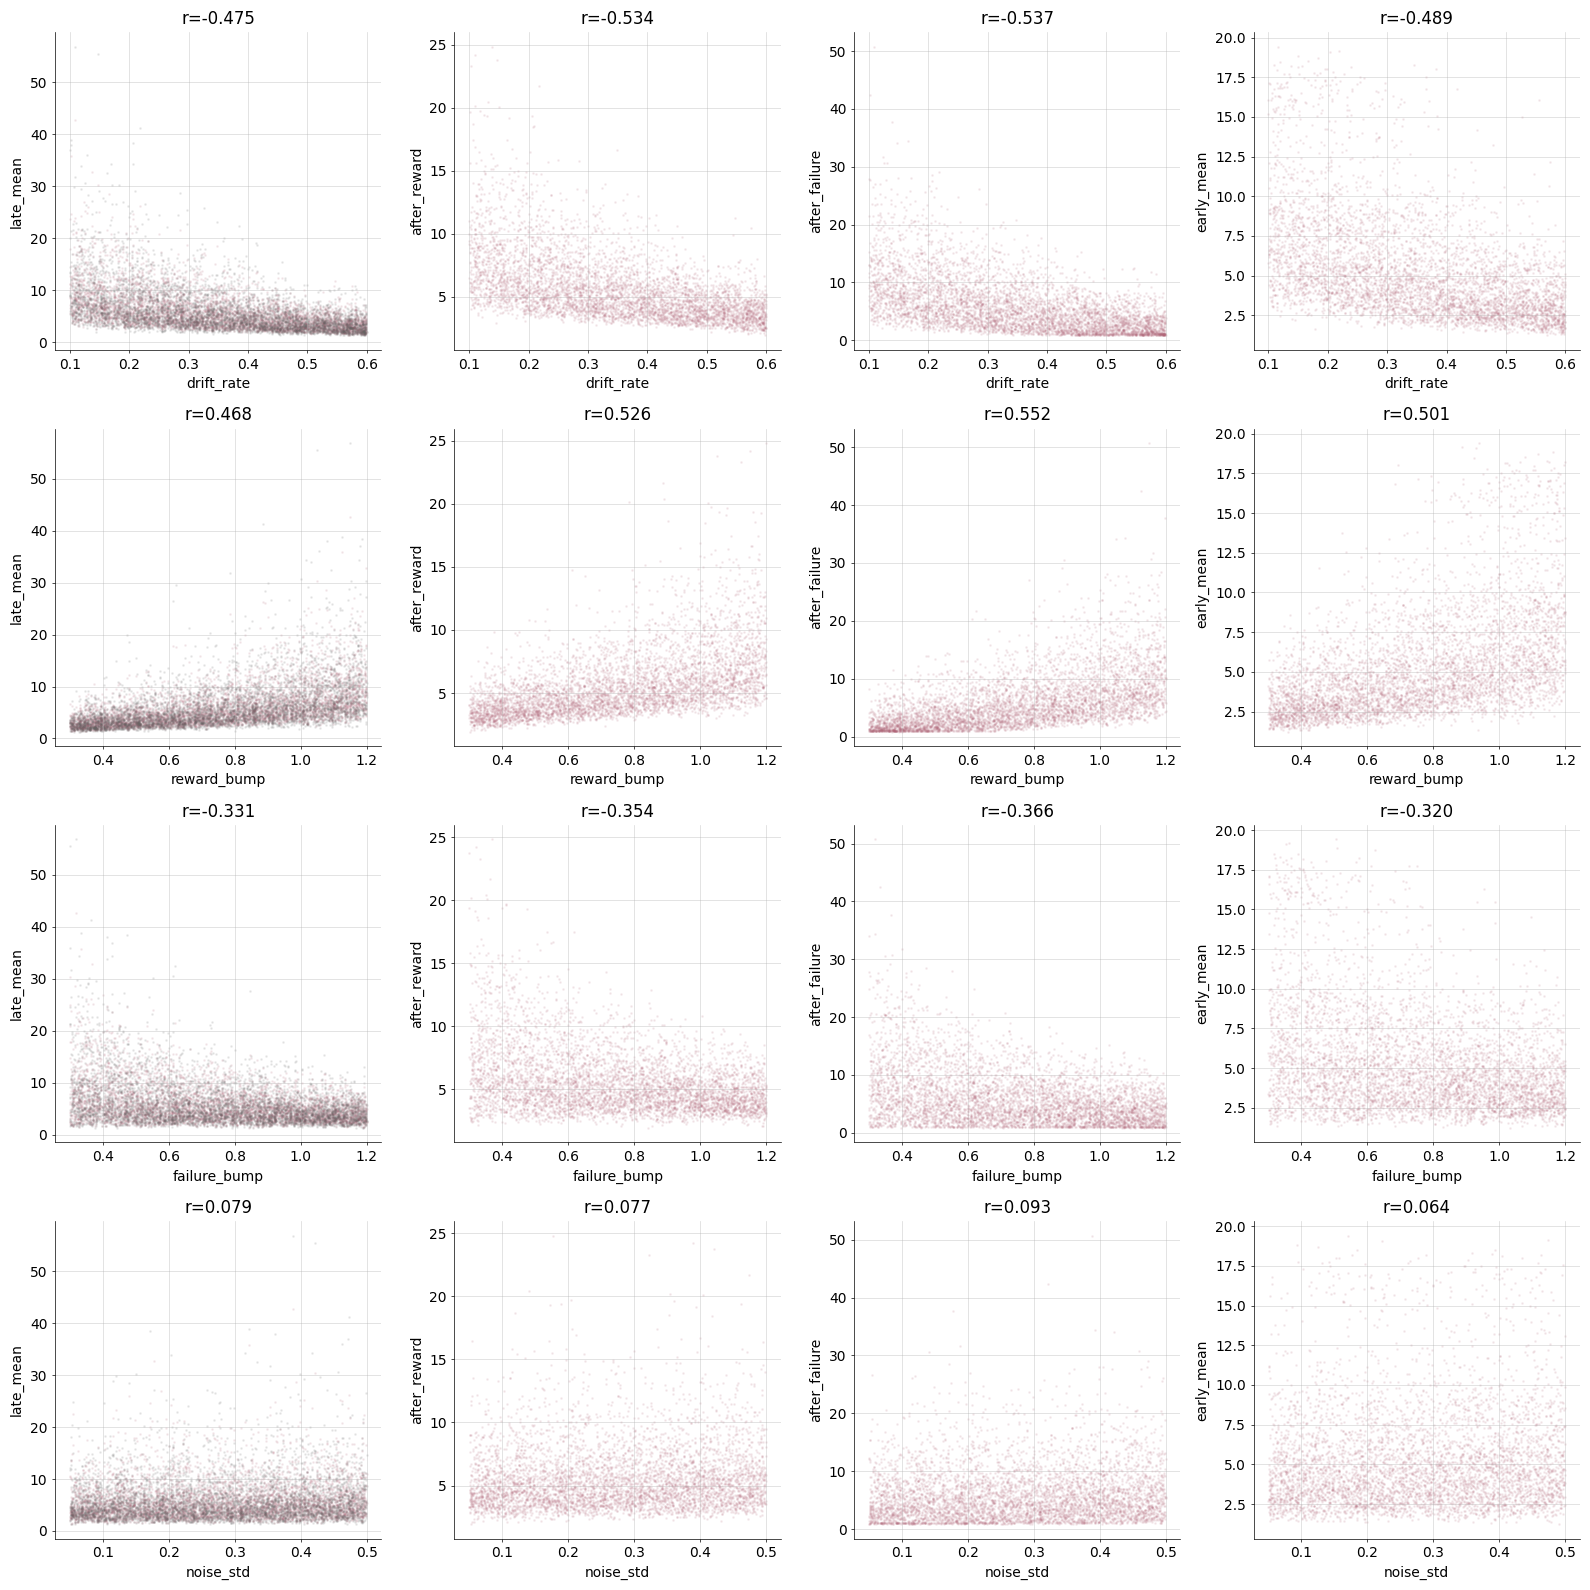

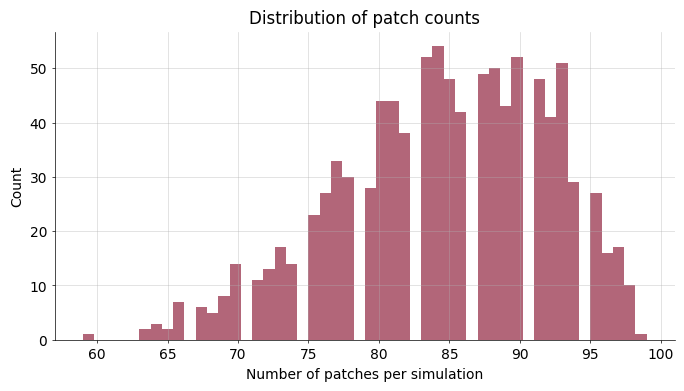

Mean patches: 84.5
Min patches: 59
Max patches: 99


In [16]:
# 1. Check if parameters actually affect summary statistics
print("\n=== PARAMETER SENSITIVITY TEST ===")
test_params = [
    jnp.array([0.05, 0.5, 0.5, 0.1]),  # very low drift
    jnp.array([0.5, 0.5, 0.5, 0.1]),   # medium drift
    jnp.array([0.95, 0.5, 0.5, 0.1]),  # high drift
]

rng_key = random.PRNGKey(42)
for i, theta in enumerate(test_params):
    rng_key, subkey = random.split(rng_key)
    window_data, stats = simulator.simulate_one_window(theta, subkey)
    
    n_patches = jnp.sum(window_data[:, 2])
    print(f"\nTheta {i}: drift={theta[0]:.2f}")
    print(f"  n_patches: {n_patches}")
    print(f"  mean_time: {stats[1]:.3f}")
    print(f"  time_after_reward: {stats[7]:.3f}")
    print(f"  time_after_failure: {stats[8]:.3f}")

# 2. Visualize parameter-statistic relationships from training data
import matplotlib.pyplot as plt

# Get training data
rng_key, data_key = random.split(rng_key)
data, _ = snle.simulate_data(data_key, n_simulations=5000)
theta_train = data['theta']['theta']
y_train = data['y']

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
key_stat_indices = [1, 7, 8, 11, 12]  # mean_time, after_reward, after_failure, early, late
key_stat_names = ['mean_time', 'after_reward', 'after_failure', 'early_mean', 'late_mean']

for i in range(4):  # parameters
    for j, (stat_idx, stat_name) in enumerate(zip(key_stat_indices, key_stat_names)):
        ax = axes[i, j] if j < 4 else axes[i, 0]
        if j < len(key_stat_indices):
            ax.scatter(theta_train[:, i], y_train[:, stat_idx], alpha=0.1, s=1)
            ax.set_xlabel(param_names[i])
            ax.set_ylabel(stat_name)
            
            # Compute correlation
            corr = jnp.corrcoef(theta_train[:, i], y_train[:, stat_idx])[0, 1]
            ax.set_title(f'r={corr:.3f}')

plt.tight_layout()
plt.show()

# 3. Check distribution of patches per simulation
rng_key, data_key = random.split(rng_key)
n_patches_list = []
for i in range(1000):
    rng_key, subkey = random.split(rng_key)
    theta = prior_fn().sample(seed=subkey)['theta']
    window_data, _ = simulator.simulate_one_window(theta, subkey)
    n_patches = jnp.sum(window_data[:, 2])
    n_patches_list.append(n_patches)

plt.figure(figsize=(8, 4))
plt.hist(n_patches_list, bins=50)
plt.xlabel('Number of patches per simulation')
plt.ylabel('Count')
plt.title('Distribution of patch counts')
plt.show()

print(f"Mean patches: {jnp.mean(jnp.array(n_patches_list)):.1f}")
print(f"Min patches: {jnp.min(jnp.array(n_patches_list)):.0f}")
print(f"Max patches: {jnp.max(jnp.array(n_patches_list)):.0f}")

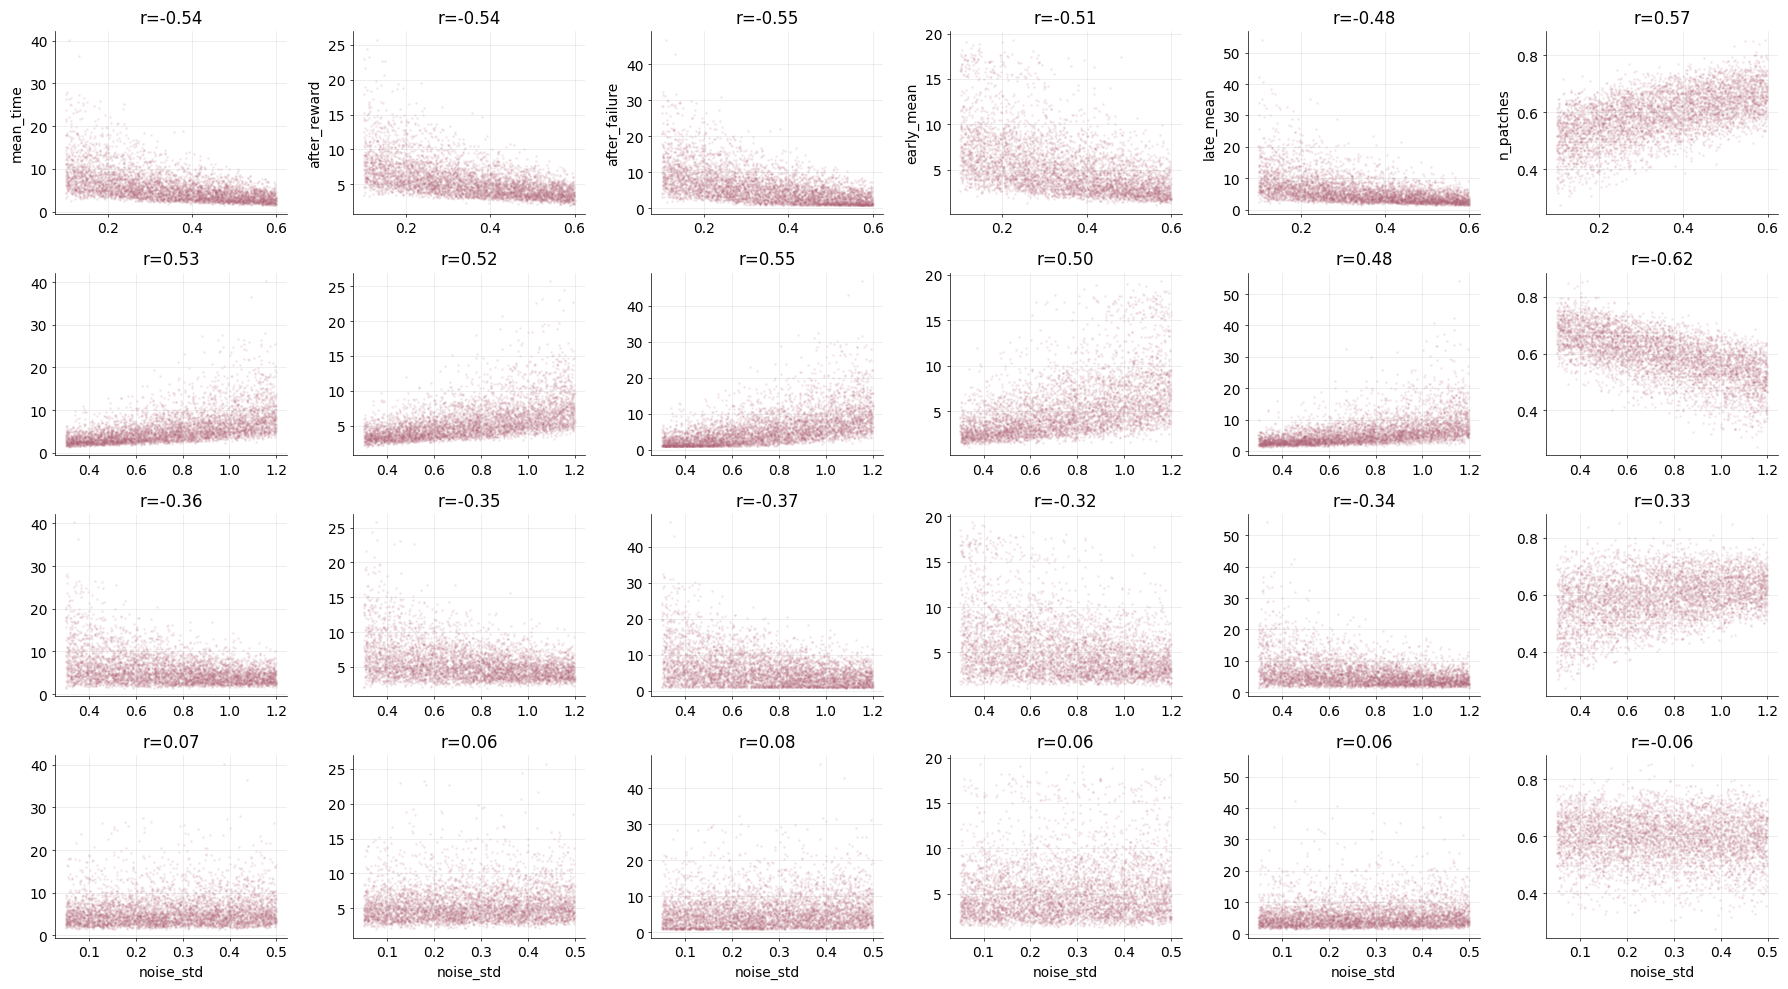


=== CORRELATION MATRIX ===
Parameter vs Key Statistics:
Param            mean_time  after_rew after_fail  n_patches
------------------------------------------------------------
drift_rate          -0.540     -0.544     -0.550      0.566
reward_bump          0.527      0.522      0.548     -0.621
failure_bump        -0.362     -0.353     -0.367      0.331
noise_std            0.069      0.063      0.080     -0.056


In [17]:
# Visualize parameter-statistic relationships from your ACTUAL training data
import matplotlib.pyplot as plt

# Extract training data that was actually used
rng_key = random.PRNGKey(123)
rng_key, data_key = random.split(rng_key)
data, _ = snle.simulate_data(data_key, n_simulations=5000)
theta_train = data['theta']['theta']
y_train = data['y']

param_names = ["drift_rate", "reward_bump", "failure_bump", "noise_std"]

# Check correlations for KEY statistics
key_stat_indices = [1, 7, 8, 11, 12, 25]  # mean_time, after_reward, after_failure, early, late, n_patches
key_stat_names = ['mean_time', 'after_reward', 'after_failure', 'early_mean', 'late_mean', 'n_patches']

fig, axes = plt.subplots(4, 6, figsize=(18, 10))

for i in range(4):  # parameters
    for j, (stat_idx, stat_name) in enumerate(zip(key_stat_indices, key_stat_names)):
        ax = axes[i, j]
        ax.scatter(theta_train[:, i], y_train[:, stat_idx], alpha=0.1, s=1)
        ax.set_xlabel(param_names[i] if i == 3 else '')
        ax.set_ylabel(stat_name if i == 0 else '')
        
        # Compute correlation
        corr = jnp.corrcoef(theta_train[:, i], y_train[:, stat_idx])[0, 1]
        ax.set_title(f'r={corr:.2f}')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print correlation matrix
print("\n=== CORRELATION MATRIX ===")
print("Parameter vs Key Statistics:")
print(f"{'Param':<15} {'mean_time':>10} {'after_rew':>10} {'after_fail':>10} {'n_patches':>10}")
print("-" * 60)
for i, pname in enumerate(param_names):
    corrs = [jnp.corrcoef(theta_train[:, i], y_train[:, idx])[0, 1] 
             for idx in [1, 7, 8, 25]]
    print(f"{pname:<15} {corrs[0]:>10.3f} {corrs[1]:>10.3f} {corrs[2]:>10.3f} {corrs[3]:>10.3f}")

In [12]:
# Test if the network learned ANYTHING
print("\n=== FORWARD MODEL TEST ===")

# Generate test data
rng_key = random.PRNGKey(999)
test_thetas = jnp.array([
    [0.2, 0.5, 0.5, 0.1],
    [0.8, 0.5, 0.5, 0.1],
    [0.5, 0.2, 0.8, 0.1],
    [0.5, 0.8, 0.2, 0.1],
])

for theta in test_thetas:
    # Simulate true data
    rng_key, subkey = random.split(rng_key)
    _, true_stats = simulator.simulate_one_window(theta, subkey)
    
    # Get posterior samples
    rng_key, subkey = random.split(rng_key)
    posterior_samples, _ = infer_parameters_snle(
        snle, snle_params, true_stats, y_mean, y_std,
        num_samples=1000, num_warmup=100, num_chains=2, rng_key=subkey
    )
    
    post_mean = posterior_samples.mean(axis=0)
    post_std = posterior_samples.std(axis=0)
    
    print(f"\nTrue:  {theta}")
    print(f"Infer: {post_mean} ± {post_std}")


=== FORWARD MODEL TEST ===

Normalizing observed statistics...
Observed stats (raw): [ 2.0357229e+01  6.3190570e+00  4.4459324e+00  9.0999997e-01
  2.8618181e-01  5.2999997e-01  4.9909920e-01  6.1652117e+00
  6.6747003e+00  3.8148568e+00  5.1440430e+00  8.4525986e+00
  5.8010211e+00 -2.4624097e-01 -2.6515775e+00  4.5921373e+00
  2.9193068e+00  5.3822269e+00  8.1458054e+00  5.2264986e+00
  9.9817604e-01  2.6120451e-01  9.7301471e-01  5.8241761e-01
  5.0471699e+01  5.8241761e-01  9.1000000e+01  1.0989012e+00
  9.0999997e-01  6.1877143e-01  7.7067775e-01  2.6105490e-01
 -2.4643533e-01  3.2316539e+00  1.2657953e-02 -1.5384531e-01
 -3.5564327e-01]
Observed stats (normalized): [ 0.424372    0.12845784  0.15128373  0.8373462  -0.74220794  0.6793774
  0.37376553  0.20046455  0.15261795  0.14163421  0.2948191   0.97014815
 -0.06112579 -1.6044244  -1.1358718  -0.32839757  0.2716592   0.10081641
 -0.0624267  -0.19460593  0.5132804  -1.2561365  -0.4656693  -0.13257626
  0.7495505  -0.13257626  0.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Parse your results
results = [
    {"true": [0.2, 0.5, 0.5, 0.1], "infer": [0.34, 0.90, 0.80, 0.11], "std": [0.034, 0.101, 0.211, 0.045]},
    {"true": [0.8, 0.5, 0.5, 0.1], "infer": [0.79, 0.45, 0.93, 0.14], "std": [0.042, 0.072, 0.196, 0.050]},
    {"true": [0.5, 0.2, 0.8, 0.1], "infer": [0.56, 0.34, 0.85, 0.09], "std": [0.026, 0.033, 0.154, 0.030]},
    {"true": [0.5, 0.8, 0.2, 0.1], "infer": [0.46, 1.02, 0.81, 0.18], "std": [0.068, 0.113, 0.218, 0.050]},
]

param_names = ["drift_rate", "reward_bump", "failure_bump", "noise_std"]

# Convert to arrays
true_vals = np.array([r["true"] for r in results])
infer_vals = np.array([r["infer"] for r in results])
std_vals = np.array([r["std"] for r in results])

print("="*80)
print("MODEL PERFORMANCE EVALUATION")
print("="*80)

# 1. Absolute errors
print("\n1. ABSOLUTE ERRORS (|true - inferred|)")
print("-" * 60)
errors = np.abs(true_vals - infer_vals)
for i, param in enumerate(param_names):
    print(f"{param:15s}: {errors[:, i]}")
    print(f"  Mean error: {np.mean(errors[:, i]):.3f}")
    print(f"  Max error:  {np.max(errors[:, i]):.3f}")

# 2. Relative errors
print("\n2. RELATIVE ERRORS (|true - inferred| / true)")
print("-" * 60)
rel_errors = np.abs(true_vals - infer_vals) / (true_vals + 1e-8)
for i, param in enumerate(param_names):
    print(f"{param:15s}: {rel_errors[:, i]}")
    print(f"  Mean rel error: {np.mean(rel_errors[:, i]):.1%}")

# 3. Coverage (is true value within 2 std of posterior mean?)
print("\n3. COVERAGE (true within ±2σ of inferred?)")
print("-" * 60)
coverage = np.abs(true_vals - infer_vals) <= 2 * std_vals
for i, param in enumerate(param_names):
    covered = np.sum(coverage[:, i])
    print(f"{param:15s}: {covered}/4 cases ({100*covered/4:.0f}%)")
    for j in range(4):
        status = "✓" if coverage[j, i] else "✗"
        z_score = (true_vals[j, i] - infer_vals[j, i]) / std_vals[j, i]
        print(f"  Test {j+1}: {status} (z={z_score:+.2f}σ)")

# 4. Parameter-specific analysis
print("\n4. PARAMETER-SPECIFIC ANALYSIS")
print("-" * 60)

for i, param in enumerate(param_names):
    print(f"\n{param.upper()}:")
    
    # Correlation between true and inferred
    corr = np.corrcoef(true_vals[:, i], infer_vals[:, i])[0, 1]
    print(f"  Correlation (true vs inferred): r = {corr:.3f}")
    
    # RMSE
    rmse = np.sqrt(np.mean((true_vals[:, i] - infer_vals[:, i])**2))
    print(f"  RMSE: {rmse:.3f}")
    
    # Bias (systematic over/under estimation)
    bias = np.mean(infer_vals[:, i] - true_vals[:, i])
    print(f"  Bias: {bias:+.3f} {'(overestimates)' if bias > 0 else '(underestimates)'}")
    
    # Mean posterior uncertainty
    mean_std = np.mean(std_vals[:, i])
    print(f"  Mean posterior std: {mean_std:.3f}")

# 5. Cross-parameter confusion
print("\n5. CROSS-PARAMETER CONFUSION")
print("-" * 60)
print("Do errors in one parameter correlate with errors in another?")
print("(High correlation = parameters are confused)")
print()

error_matrix = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        if i != j:
            corr = np.corrcoef(errors[:, i], errors[:, j])[0, 1]
            error_matrix[i, j] = corr
            if abs(corr) > 0.7:
                print(f"  {param_names[i]} ↔ {param_names[j]}: r = {corr:.3f} ⚠️")

# 6. Overall summary
print("\n" + "="*80)
print("OVERALL SUMMARY")
print("="*80)

# Count well-recovered parameters (error < 20% of range)
param_ranges = np.array([1.0, 0.9, 0.9, 0.15])  # approximate prior ranges
well_recovered = np.sum(errors < 0.2 * param_ranges, axis=0)

print(f"\nWell-recovered in majority of tests (>50%):")
for i, param in enumerate(param_names):
    pct = 100 * well_recovered[i] / 4
    status = "✓" if well_recovered[i] >= 2 else "✗"
    print(f"  {status} {param:15s}: {well_recovered[i]}/4 ({pct:.0f}%)")

# Overall score
total_well_recovered = np.sum(well_recovered)
max_possible = 16
print(f"\nOverall recovery score: {total_well_recovered}/{max_possible} ({100*total_well_recovered/max_possible:.0f}%)")

# Grade
score_pct = 100 * total_well_recovered / max_possible
if score_pct >= 80:
    grade = "A - Excellent"
elif score_pct >= 65:
    grade = "B - Good"
elif score_pct >= 50:
    grade = "C - Fair"
else:
    grade = "D - Poor"

print(f"Grade: {grade}")

# Recommendations
print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)

if np.mean(errors[:, 0]) < 0.1:
    print("✓ drift_rate: Recovering well")
else:
    print("⚠ drift_rate: Needs improvement")

if np.corrcoef(errors[:, 1], errors[:, 2])[0, 1] > 0.5:
    print("⚠ reward_bump and failure_bump are confused - consider:")
    print("  - Fix one parameter")
    print("  - Add directional statistics")
    print("  - Use reparameterization")
else:
    print("✓ reward_bump and failure_bump: Not strongly confused")

if np.mean(errors[:, 3]) > 0.05:
    print("⚠ noise_std: Difficult to recover - consider:")
    print("  - Narrower prior")
    print("  - Fix this parameter")
else:
    print("✓ noise_std: Recovering reasonably well")

MODEL PERFORMANCE EVALUATION

1. ABSOLUTE ERRORS (|true - inferred|)
------------------------------------------------------------
drift_rate     : [0.14 0.01 0.06 0.04]
  Mean error: 0.063
  Max error:  0.140
reward_bump    : [0.4  0.05 0.14 0.22]
  Mean error: 0.203
  Max error:  0.400
failure_bump   : [0.3  0.43 0.05 0.61]
  Mean error: 0.348
  Max error:  0.610
noise_std      : [0.01 0.04 0.01 0.08]
  Mean error: 0.035
  Max error:  0.080

2. RELATIVE ERRORS (|true - inferred| / true)
------------------------------------------------------------
drift_rate     : [0.69999997 0.0125     0.12       0.08      ]
  Mean rel error: 22.8%
reward_bump    : [0.79999998 0.1        0.69999997 0.275     ]
  Mean rel error: 46.9%
failure_bump   : [0.59999999 0.85999998 0.0625     3.04999985]
  Mean rel error: 114.3%
noise_std      : [0.09999999 0.39999996 0.09999999 0.79999992]
  Mean rel error: 35.0%

3. COVERAGE (true within ±2σ of inferred?)
-----------------------------------------------------

/opt/miniconda3/envs/sbi_jax_py311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/sbi_jax_py311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Normalizing observed statistics...
Observed stats (raw): [ 1.4739842e+01  5.0865874e+00  3.7390552e+00  8.5999995e-01
  3.4698701e-01  5.6999999e-01  4.9507573e-01  5.4239426e+00
  4.5472541e+00  3.4726498e+00  4.1544938e+00  3.0487971e+00
  6.9086475e+00  5.1650977e-01  3.8598504e+00  5.1592741e+00
  2.1218073e+00  4.2353678e+00  6.5828600e+00  4.4610529e+00
  9.9720514e-01  2.7080965e-01  9.5291954e-01  6.6279072e-01
  5.1192982e+01  6.6279072e-01  8.6000000e+01  1.1627907e+00
  8.5999995e-01  6.4024460e-01  9.1362691e-01  2.7561218e-01
 -2.3982139e-01  2.5845723e+00  5.2428775e-02  3.3735514e-01
  5.3933334e-01]
Observed stats (normalized): [-0.20348705 -0.20616104 -0.13245717  0.17999452  0.04015332  1.5113212
 -0.67180365 -0.08320589 -0.29590786 -0.01679036 -0.07324408 -0.6901937
  0.19031209  2.2009346   1.0224879  -0.20269126 -0.22042164 -0.2319534
 -0.3413112  -0.38313377  0.42865837 -0.87928724 -0.9916462   0.82442516
  1.0657477   0.82442516  0.17999332 -0.255023    0.179994

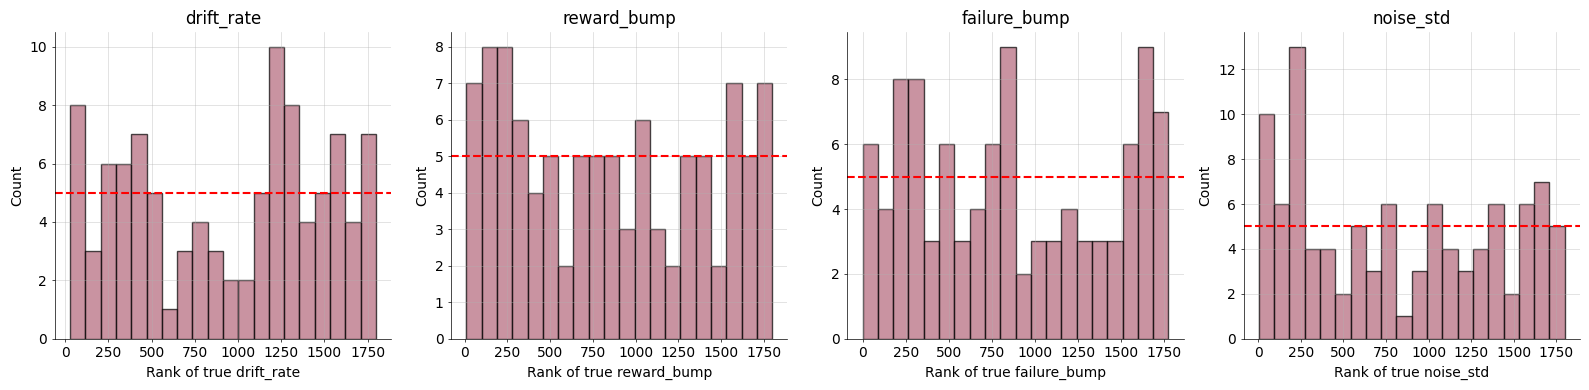

In [14]:
# Full SBC test
n_sbc_tests = 100
ranks = {param: [] for param in param_names}

for test in range(n_sbc_tests):
    rng_key, subkey1, subkey2 = random.split(rng_key, 3)
    
    # Sample from prior
    true_theta = prior_fn().sample(seed=subkey1)['theta']
    
    # Simulate data
    _, observed_stats = simulator.simulate_one_window(true_theta, subkey2)
    
    # Infer
    posterior_samples, _ = infer_parameters_snle(
        snle, snle_params, observed_stats, y_mean, y_std,
        num_samples=1000, num_warmup=100, num_chains=2, rng_key=subkey2
    )
    
    # Compute ranks
    for i in range(4):
        rank = (posterior_samples[:, i] < true_theta[i]).sum()
        ranks[param_names[i]].append(rank)

# Plot rank histograms (should be uniform if calibrated)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, param in enumerate(param_names):
    axes[i].hist(ranks[param], bins=20, alpha=0.7, edgecolor='k')
    axes[i].axhline(n_sbc_tests/20, color='r', linestyle='--', label='expected')
    axes[i].set_xlabel(f'Rank of true {param}')
    axes[i].set_ylabel('Count')
    axes[i].set_title(param)
plt.tight_layout()
plt.show()